In [0]:
# Replace with your actual storage account name and key
spark.conf.set(
"fs.azure.account.key.projectlinkedinjobs.dfs.core.windows.net",
"<Account Key>"
)

In [0]:
gold = spark.read.format("delta").load(
    "abfss://lakehouse@projectlinkedinjobs.dfs.core.windows.net/gold/curated_postings/"
)
gold.show(5, truncate=False)
print("Rows:", gold.count())

+------------------------------------------------------------------------------------------------------------------------------------+---------------------------------------------------------------------------+--------------------------+-------------------+-----------+--------------+------------------------+----------+--------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------------------------------

In [0]:
# check the data types
gold.printSchema()

root
 |-- job_link: string (nullable = true)
 |-- job_title: string (nullable = true)
 |-- company: string (nullable = true)
 |-- job_location: string (nullable = true)
 |-- search_city: string (nullable = true)
 |-- search_country: string (nullable = true)
 |-- search_position: string (nullable = true)
 |-- job_level: string (nullable = true)
 |-- job_type: string (nullable = true)
 |-- job_skills: string (nullable = true)
 |-- job_summary: string (nullable = true)



In [0]:
# Ensure Identity and target columns have no null values
from pyspark.sql.functions import col
gold = gold.filter(col("job_link").isNotNull() & col("job_type").isNotNull())

In [0]:
# Remove duplicates first (rechecking)
gold = gold.dropDuplicates()

# Keep one row per job_link 
gold = gold.dropDuplicates(["job_link"])

print("Rows:", gold.count())
print("Distinct job_link:", gold.select("job_link").distinct().count())


Rows: 1348424
Distinct job_link: 1348424


In [0]:
# normalize text
# make sure all the text columns doesnt have leading and trailing spaces
from pyspark.sql.functions import trim

string_cols = [c for c,t in gold.dtypes if t == "string"]
for c in string_cols:
    gold = gold.withColumn(c, trim(col(c)))

In [0]:
# lowercase descriptive columnns
from pyspark.sql.functions import lower

nlp_cols = ["job_summary", "job_skills"]

for c in nlp_cols:
    gold = gold.withColumn(c, lower(col(c)))


In [0]:
# Remove extra spaces in between the texts
from pyspark.sql.functions import regexp_replace
gold = gold.withColumn(c, trim(regexp_replace(col(c), r"\s+", " ")))

In [0]:
# check unique types
gold.select("job_type").distinct().show(truncate=False)

+--------+
|job_type|
+--------+
|Remote  |
|Onsite  |
|Hybrid  |
+--------+



In [0]:
gold.select("job_title").distinct().count()


583976

In [0]:
gold.select("job_title").show(20)

+--------------------+
|           job_title|
+--------------------+
|Health and Safety...|
|Mental Health Cer...|
|Rocket Engine Sys...|
|Dialysis Technici...|
|Travel RN Med,Sur...|
|Interventional Sp...|
|Natural Resources...|
|Clinical Supervis...|
|Facilities Engine...|
|Senior Manager, V...|
|Replenishment Lea...|
|Manager in Traini...|
|Ultrasound Techno...|
|Operating Room As...|
|Direct Support Pr...|
|Sous Chef , Full ...|
|      Supply Planner|
|Hourly Supervisor...|
|Cable Field Techn...|
|           Cafe Lead|
+--------------------+
only showing top 20 rows


In [0]:
from pyspark.sql.functions import col, regexp_replace, split, trim

df_cleaned = gold.withColumn(
    "job_title",
    trim(
        split(
            regexp_replace(col("job_title"), r"[\n,]+", ","),  # normalize separators
            ","
        )[0]  # take only the FIRST title
    )
)


In [0]:
df_cleaned.select("job_title").show(20)

+--------------------+
|           job_title|
+--------------------+
|Registered Nurse ...|
|  Production Manager|
|Environmental Ser...|
|       Environmental|
|Travel Allied Hea...|
|Recruitment Consu...|
|LEAD SALES ASSOCIATE|
|Life Cafe Shift S...|
|       Audit Manager|
|Juvenile Correcti...|
|  Composite engineer|
|Quality Control M...|
|Retail Guest Expe...|
|Stagiaire univers...|
|System Test Techn...|
|     Store Associate|
|       Store Manager|
|Registered Nurse ...|
|Area Cleaning Sup...|
|    Retail Associate|
+--------------------+
only showing top 20 rows


In [0]:
df_cleaned.select("job_title").distinct().count()

316104

In [0]:
from pyspark.sql.functions import col, lower, when

df = df_cleaned.withColumn("title_lc", lower(col("job_title")))


In [0]:
# # df = df.withColumn(
# #     "job_sector",
    
# #     # 1) Technology
# #     when(
# #         col("title_lc").rlike(
# #             "software|developer|engineer|programmer|it |it$|data |data$|cloud|devops|machine learning|ml engineer|ai|cyber|security"
# #         ),
# #         "Technology"
# #     )

# #     # 2) Healthcare
# #     .when(
# #         col("title_lc").rlike(
# #             "nurse| rn\b|doctor|physician|clinic|clinical|medical|healthcare|pharmacist|pharmacy|dentist|therapist"
# #         ),
# #         "Healthcare"
# #     )

# #     # 3) Finance & Accounting
# #     .when(
# #         col("title_lc").rlike(
# #             "finance|financial|accountant|accounting|auditor|tax"
# #         ),
# #         "Finance & Accounting"
# #     )

# #     # 4) Sales & Marketing
# #     .when(
# #         col("title_lc").rlike(
# #             "sales|account executive|business development|marketing|brand|digital marketing|social media"
# #         ),
# #         "Sales & Marketing"
# #     )

# #     # 5) Customer Service
# #     .when(
# #         col("title_lc").rlike(
# #             "customer service|call center|support specialist|help desk"
# #         ),
# #         "Customer Service"
# #     )

# #     # 6) Education
# #     .when(
# #         col("title_lc").rlike(
# #             "teacher|professor|lecturer|instructor|education"
# #         ),
# #         "Education"
# #     )

# #     # 7) Human Resources
# #     .when(
# #         col("title_lc").rlike(
# #             r"\bhr\b|human resources|recruiter|talent acquisition"
# #         ),
# #         "Human Resources"
# #     )

# #     # 8) Project / Program / Operations
# #     .when(
# #         col("title_lc").rlike(
# #             "project manager|program manager|scrum master|pmo|operations manager"
# #         ),
# #         "Project / Program / Operations"
# #     )

# #     # 9) Business & Management (general managers etc.)
# #     .when(
# #         col("title_lc").rlike(
# #             "manager|director|vp|head of|lead "
# #         ),
# #         "Business & Management"
# #     )

# #     # 10) Everything else
# #     .otherwise("Other")
# # )


# from pyspark.sql.functions import col, lower, when

# # 1) Helper lowercase column
# df_roles = df.withColumn("title_lc", lower(col("job_title")))

# # 2) Map to broad job roles
# df_roles = df_roles.withColumn(
#     "job_role",
    
#     # ---- Technology & Data (software, IT, data) ----
#     when(
#         col("title_lc").rlike(
#             "software|developer|programmer|data scientist|data engineer|data analyst|"
#             "machine learning|ml engineer|artificial intelligence|ai |cloud|devops|"
#             "it | it$|cyber|security engineer|network engineer"
#         ),
#         "Technology & Data"
#     )
    
#     # ---- Engineering (non-IT) ----
#     .when(
#         col("title_lc").rlike(
#             "engineer|engineering|mechanical|electrical|civil|chemical|industrial|"
#             "manufacturing|quality engineer|maintenance engineer"
#         ),
#         "Engineering"
#     )
    
#     # ---- Healthcare ----
#     .when(
#         col("title_lc").rlike(
#             "nurse| rn\\b|doctor|physician|clinic|clinical|medical|healthcare|"
#             "pharmacist|pharmacy|dentist|therapist|hospital"
#         ),
#         "Healthcare"
#     )
    
#     # ---- Finance & Accounting ----
#     .when(
#         col("title_lc").rlike(
#             "accountant|accounting|finance|financial analyst|controller|audit|auditor|tax"
#         ),
#         "Finance & Accounting"
#     )
    
#     # ---- Sales & Marketing ----
#     .when(
#         col("title_lc").rlike(
#             "sales|account executive|business development|bd manager|inside sales|outside sales|"
#             "marketing|brand|digital marketing|social media|seo|sem|content marketing"
#         ),
#         "Sales & Marketing"
#     )
    
#     # ---- Education & Training ----
#     .when(
#         col("title_lc").rlike(
#             "teacher|professor|lecturer|instructor|trainer|training|education"
#         ),
#         "Education & Training"
#     )
    
#     # ---- Human Resources ----
#     .when(
#         col("title_lc").rlike(
#             "\\bhr\\b|human resources|recruiter|talent acquisition|people partner|people operations"
#         ),
#         "Human Resources"
#     )
    
#     # ---- Customer Service & Support ----
#     .when(
#         col("title_lc").rlike(
#             "customer service|call center|contact center|support specialist|help desk|"
#             "client service|customer success"
#         ),
#         "Customer Service & Support"
#     )
    
#     # ---- Project / Operations / Supply Chain ----
#     .when(
#         col("title_lc").rlike(
#             "project manager|program manager|scrum master|pmo|operations manager|"
#             "operations lead|supply chain|logistics|warehouse|procurement|buyer|coordinator"
#         ),
#         "Project / Operations"
#     )
    
#     # ---- Creative / Design / Media ----
#     .when(
#         col("title_lc").rlike(
#             "designer|design|graphic|ux|ui|product designer|illustrator|creative|"
#             "copywriter|writer|editor|photograph|video|videograph|media|content creator"
#         ),
#         "Creative / Design / Media"
#     )
    
#     # ---- Business & Management (remaining managers) ----
#     .when(
#         col("title_lc").rlike(
#             "manager|director|vp|vice president|head of|lead "
#         ),
#         "Business & Management"
#     )
    
#     # ---- Everything else ----
#     .otherwise("Other")
# )

# # 3) Drop helper column if you like
# df_roles = df_roles.drop("title_lc")

from pyspark.sql.functions import col, lower, when

df_roles = df.withColumn("title_lc", lower(col("job_title")))

df_roles = df_roles.withColumn(
    "job_role",

    # ---- Technology & Data ----
    when(
        col("title_lc").rlike(
            "software|developer|programmer|data scientist|data engineer|data analyst|"
            "machine learning|ml engineer|ai |artificial intelligence|cloud|devops|"
            " it |it$|cyber|security engineer|network engineer"
        ),
        "Technology & Data"
    )

    # ---- Engineering (non-IT) ----
    .when(
        col("title_lc").rlike(
            "engineer|engineering|mechanical|electrical|civil|chemical|industrial|"
            "manufacturing engineer|quality engineer"
        ),
        "Engineering"
    )

    # ---- Healthcare ----
    .when(
        col("title_lc").rlike(
            "nurse| rn\\b|doctor|physician|clinic|clinical|medical|healthcare|"
            "pharmacist|pharmacy|dentist|therapist|hospital"
        ),
        "Healthcare"
    )

    # ---- Finance & Accounting ----
    .when(
        col("title_lc").rlike(
            "accountant|accounting|finance|financial analyst|controller|audit|auditor|tax"
        ),
        "Finance & Accounting"
    )

    # ---- Sales & Marketing ----
    .when(
        col("title_lc").rlike(
            "sales|account executive|business development|bd manager|inside sales|outside sales|"
            "marketing|brand|digital marketing|social media|seo|sem|content marketing"
        ),
        "Sales & Marketing"
    )

    # ---- Education & Training ----
    .when(
        col("title_lc").rlike(
            "teacher|professor|lecturer|instructor|trainer|training|education"
        ),
        "Education & Training"
    )

    # ---- Human Resources ----
    .when(
        col("title_lc").rlike(
            "\\bhr\\b|human resources|recruiter|talent acquisition|people partner|people operations"
        ),
        "Human Resources"
    )

    # ---- Customer Service & Support ----
    .when(
        col("title_lc").rlike(
            "customer service|call center|contact center|support specialist|help desk|"
            "client service|customer success"
        ),
        "Customer Service & Support"
    )

    # ---- Project / Operations ----
    .when(
        col("title_lc").rlike(
            "project manager|program manager|scrum master|pmo|operations manager|"
            "operations lead|supply chain|logistics manager|warehouse manager|procurement manager"
        ),
        "Project / Operations"
    )

    # ---- Creative / Design / Media ----
    .when(
        col("title_lc").rlike(
            "designer|design|graphic|ux|ui|product designer|illustrator|creative|"
            "copywriter|writer|editor|photograph|video|videograph|media|content creator"
        ),
        "Creative / Design / Media"
    )

    # ---- NEW: Hospitality & Retail ----
    .when(
        col("title_lc").rlike(
            "waiter|waitress|server|bartender|barista|chef|cook|kitchen|restaurant|"
            "cafe|café|hotel|hostess|front desk|housekeeping|housekeeper|concierge|"
            "hospitality|cashier|retail|store associate|shop assistant|store manager"
        ),
        "Hospitality & Retail"
    )

    # ---- NEW: Administrative & Office Support ----
    .when(
        col("title_lc").rlike(
            "administrative assistant|admin assistant|office assistant|office manager|"
            "receptionist|secretary|office clerk|executive assistant|personal assistant|\\bpa\\b|"
            "administrative coordinator"
        ),
        "Administrative & Office Support"
    )

    # ---- NEW: Logistics & Transportation ----
    .when(
        col("title_lc").rlike(
            "driver|delivery|courier|truck|truck driver|bus driver|rider|motorbike|"
            "transportation|transport driver|forklift"
        ),
        "Logistics & Transportation"
    )

    # ---- NEW: Skilled Trades & Maintenance ----
    .when(
        col("title_lc").rlike(
            "technician|mechanic|electrician|plumber|carpenter|welder|installer|"
            "hvac|maintenance worker|maintenance technician"
        ),
        "Skilled Trades & Maintenance"
    )

    # ---- Generic Business & Management (catch-all managers) ----
    .when(
        col("title_lc").rlike("manager|director|vp|vice president|head of|lead "),
        "Business & Management"
    )

    # ---- Everything else ----
    .otherwise("Other")
)

df_roles = df_roles.drop("title_lc")



In [0]:
df = df.drop("title_lc")


In [0]:
df_roles.groupBy("job_role").count().orderBy("count", ascending=False).show(50, False)


+-------------------------------+------+
|job_role                       |count |
+-------------------------------+------+
|Other                          |520174|
|Healthcare                     |209045|
|Business & Management          |155086|
|Engineering                    |77300 |
|Sales & Marketing              |73152 |
|Hospitality & Retail           |66701 |
|Finance & Accounting           |42829 |
|Education & Training           |37963 |
|Technology & Data              |34770 |
|Skilled Trades & Maintenance   |30358 |
|Project / Operations           |26887 |
|Creative / Design / Media      |24134 |
|Customer Service & Support     |22636 |
|Administrative & Office Support|12532 |
|Human Resources                |9360  |
|Logistics & Transportation     |5497  |
+-------------------------------+------+



+-------------------------------+------+
|job_role                       |count |
+-------------------------------+------+
|Other                          |520174|
|Healthcare                     |209045|
|Business & Management          |155086|
|Engineering                    |77300 |
|Sales & Marketing              |73152 |
|Hospitality & Retail           |66701 |
|Finance & Accounting           |42829 |
|Education & Training           |37963 |
|Technology & Data              |34770 |
|Skilled Trades & Maintenance   |30358 |
|Project / Operations           |26887 |
|Creative / Design / Media      |24134 |
|Customer Service & Support     |22636 |
|Administrative & Office Support|12532 |
|Human Resources                |9360  |
|Logistics & Transportation     |5497  |
+-------------------------------+------+



<Axes: title={'center': 'Job Role Distribution'}, xlabel='job_role'>

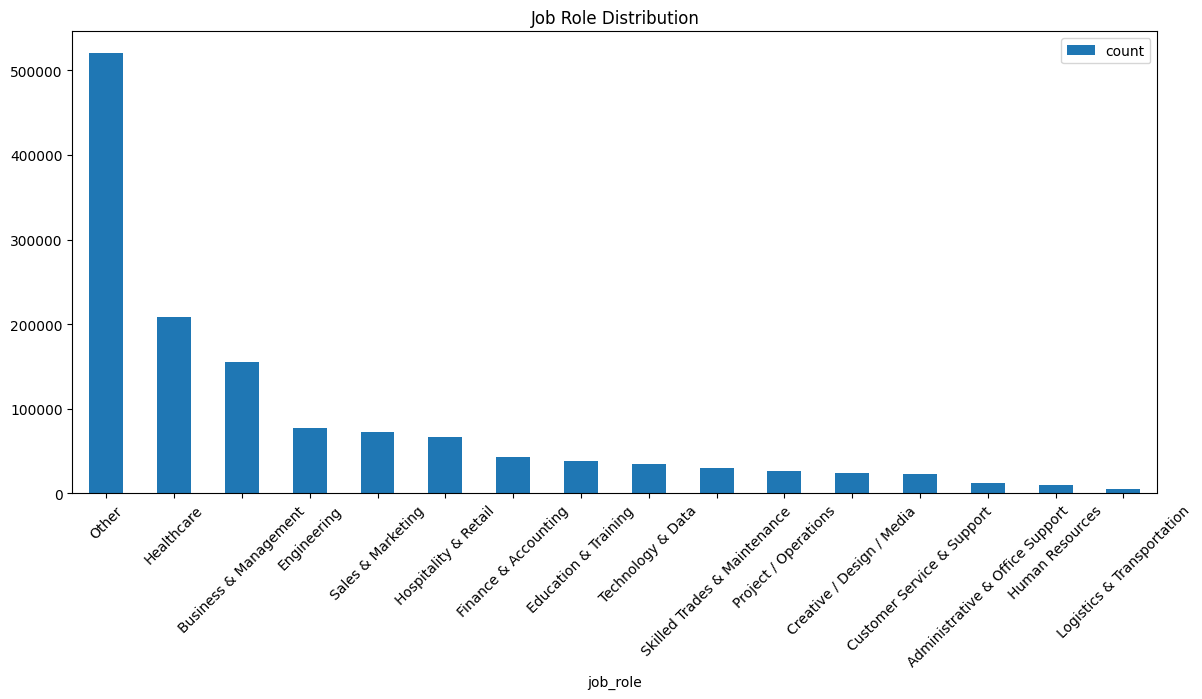

In [0]:
import matplotlib.pyplot as plt

# counts = df.groupBy("job_sector").count().orderBy("count", ascending=False).toPandas()
# plt.figure(figsize=(12,6))
# plt.bar(counts["job_sector"], counts["count"])
# plt.xticks(rotation=45, ha="right")
# plt.title("Job Sector Distribution")
# plt.ylabel("Count")
# plt.show()


df_roles.groupBy("job_role").count().orderBy("count", ascending=False).show(50, False)
pdf = df_roles.groupBy("job_role").count().orderBy("count", ascending=False).toPandas()

pdf.plot(kind="bar", x="job_role", y="count", figsize=(14,6), title="Job Role Distribution", rot=45)


In [0]:
df_roles.filter(col("job_role") == "Other").select("job_title").show(100, False)


+--------------------------------------------------------------------+
|job_title                                                           |
+--------------------------------------------------------------------+
|Rocket Engine System Performance and Trades Analyst (R37777)        |
|Interventional Specialist                                           |
|Natural Resources Program Leader                                    |
|Ultrasound Technologist                                             |
|Operating Room Assistant                                            |
|Direct Support Professional 3 (DSP3)                                |
|Supply Planner                                                      |
|Relationship Banker                                                 |
|Research Scientist – Multiscale Physics                             |
|Academic tutoring Private Tutoring Jobs Norton                      |
|Experienced Appliance Repair Professional (3x                       |
|Shift

In [0]:
keyword_to_role = {
    # Healthcare
    "nurse": "Healthcare",
    "registered nurse": "Healthcare",
    "clinic": "Healthcare",
    "clinical": "Healthcare",
    "pharmacy": "Healthcare",
    "pharmacist": "Healthcare",
    "hospital": "Healthcare",
    "doctor": "Healthcare",
    "dentist": "Healthcare",
    "therapist": "Healthcare",

    # Technology & Data
    "data scientist": "Technology & Data",
    "data analyst": "Technology & Data",
    "machine learning": "Technology & Data",
    "ml engineer": "Technology & Data",
    "ai engineer": "Technology & Data",
    "software engineer": "Technology & Data",
    "developer": "Technology & Data",
    "backend": "Technology & Data",
    "front end": "Technology & Data",
    "full stack": "Technology & Data",

    # Business & Management
    "business analyst": "Business & Management",
    "project manager": "Business & Management",
    "product manager": "Business & Management",
    "manager": "Business & Management",
    "director": "Business & Management",
    "supervisor": "Business & Management",
    "coordinator": "Business & Management",

    # Sales & Marketing
    "sales": "Sales & Marketing",
    "account executive": "Sales & Marketing",
    "account manager": "Sales & Marketing",
    "business development": "Sales & Marketing",
    "marketing": "Sales & Marketing",
    "seo": "Sales & Marketing",
    "social media": "Sales & Marketing",

    # Education & Training
    "teacher": "Education & Training",
    "instructor": "Education & Training",
    "lecturer": "Education & Training",
    "professor": "Education & Training",
    "trainer": "Education & Training",
}


In [0]:
mapping_broadcast = spark.sparkContext.broadcast(keyword_to_role)


In [0]:
from pyspark.sql.functions import col, udf
from pyspark.sql.types import StringType

def refine_role(job_role, job_title):
    # keep existing non-"Other" roles
    if job_role != "Other" or job_title is None:
        return job_role

    title = job_title.lower()
    for kw, new_role in mapping_broadcast.value.items():
        if kw in title:
            return new_role

    # nothing matched → stay as "Other"
    return job_role   # which is "Other"

refine_role_udf = udf(refine_role, StringType())



In [0]:
df = df.withColumn(
    "job_title ",
    refine_role_udf(col("job_role"), col("job_title"))
)


{"ts": "2025-11-16 13:35:43.250", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `job_role` cannot be resolved. Did you mean one of the following? [`job_title`, `job_type`, `job_level`, `job_link`, `job_sector`]. SQLSTATE: 42703", "context": {"file": "<command-6157404431594093>, line 3 in cell [49]", "line": "", "fragment": "col", "errorClass": "UNRESOLVED_COLUMN.WITH_SUGGESTION"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o1326.withColumn.\n: org.apache.spark.sql.catalyst.ExtendedAnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `job_role` cannot be resolved. Did you mean one of the following? [`job_title`, `job_type`, `job_level`, `job_link`, `job_sector`]. SQLSTATE: 42703;\n'Project [job_link#314, job_title#660, company#338, job_location#350, search_city#362, search_country#374, sear

---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-6157404431594093>, line 1
----> 1 df = df.withColumn(
      2     "job_title ",
      3     refine_role_udf(col("job_role"), col("job_title"))
      4 )

File /databricks/spark/python/pyspark/instrumentation_utils.py:47, in _wrap_function.<locals>.wrapper(*args, **kwargs)
     45 start = time.perf_counter()
     46 try:
---> 47     res = func(*args, **kwargs)
     48     logger.log_success(
     49         module_name, class_name, function_name, time.perf_counter() - start, signature
     50     )
     51     return res

File /databricks/spark/python/pyspark/sql/dataframe.py:6331, in DataFrame.withColumn(self, colName, col)
   6326 if not isinstance(col, Column):
   6327     raise PySparkTypeError(
   6328         errorClass="NOT_COLUMN",
   6329         messageParameters={"arg_name": "col", "arg_type": type(col).__name__}

In [0]:
import pandas as pd

# Lowercase titles for easier matching
df["job_title_clean"] = df["job_title"].fillna("").str.lower()

def refine_job_role(row):
    # keep non-"Other" as they are
    if row["job_role"] != "Other":
        return row["job_role"]
    
    title = row["job_title_clean"]
    
    # check each keyword; first match wins
    for kw, new_role in keyword_to_role.items():
        if kw in title:
            return new_role
    
    # if nothing matched, stay as Other
    return "Other"

df["job_role_refined"] = df.apply(refine_job_role, axis=1)


---------------------------------------------------------------------------
TypeError                                 Traceback (most recent call last)
File <command-6157404431594087>, line 4
      1 import pandas as pd
      3 # Lowercase titles for easier matching
----> 4 df["job_title_clean"] = df["job_title"].fillna("").str.lower()
      6 def refine_job_role(row):
      7     # keep non-"Other" as they are
      8     if row["job_role"] != "Other":

TypeError: 'Column' object is not callable